In [1]:
from __future__ import annotations
import argparse
import csv
import shutil
from pathlib import Path
 
import numpy as np
from PIL import Image
from ultralytics import YOLO
 
COCO_CAT, COCO_DOG = 15, 16
 

In [3]:
SRC         = Path("content/cats-and-dogs-for-classification/cats_dogs/train")
OUT_CROP    = Path("out/train_crop075")
OUT_MISSING = Path("out/train_no_animal")
BBOX_CSV    = Path("out/bboxes_train.csv")   # None para no guardarlo

COVERAGE = 0.75
CONF     = 0.25
BATCH    = 16
LIMIT    = 0          # 0 = todas; pon 200 para una prueba rapida
MODEL    = "yolov8n.pt"
DEVICE   = None       # "cpu", 0, ... ; None = auto
EXTS     = [".jpg", ".jpeg", ".png"]

In [4]:
model = YOLO(MODEL)

In [5]:
def square_crop_box(W, H, x1, y1, x2, y2, coverage):
    bw, bh = x2 - x1, y2 - y1
    cx, cy = x1 + bw / 2.0, y1 + bh / 2.0

    side = max(bw, bh) / max(coverage, 1e-6)
    side = min(side, W, H)                 # no puede superar la imagen
    half = side / 2.0

    left, right = cx - half, cx + half
    top, bottom = cy - half, cy + half

    # desplazar dentro de los bordes SIN cambiar el tamano
    if left < 0:    right -= left;        left = 0.0
    if top < 0:     bottom -= top;        top = 0.0
    if right > W:   left -= (right - W);  right = float(W)
    if bottom > H:  top -= (bottom - H);  bottom = float(H)

    left = max(0, int(round(left)));   top = max(0, int(round(top)))
    right = min(W, int(round(right))); bottom = min(H, int(round(bottom)))
    return left, top, right, bottom

In [6]:
def build_dataset(model, src, out_crop, out_missing, coverage,
                  conf=0.25, batch=16, limit=0, exts=(".jpg",".jpeg",".png"),
                  bbox_csv=None, device=None):
    paths = sorted(p for p in src.rglob("*") if p.suffix.lower() in exts)
    if limit:
        paths = paths[:limit]
    print(f"{len(paths)} imagenes en {src}  |  coverage={coverage}")

    kept = missing = capped = 0
    cov_after, csv_rows = [], []

    for i in range(0, len(paths), batch):
        chunk = paths[i:i + batch]
        results = model([str(p) for p in chunk], classes=[COCO_CAT, COCO_DOG],
                        conf=conf, device=device, verbose=False)
        for path, res in zip(chunk, results):
            rel = path.relative_to(src)            # conserva subcarpeta de clase

            if len(res.boxes) == 0:
                dst = out_missing / rel
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy2(path, dst)
                missing += 1
                continue

            k = int(res.boxes.conf.argmax())
            x1, y1, x2, y2 = res.boxes.xyxy[k].tolist()
            confv = float(res.boxes.conf[k]); cls = int(res.boxes.cls[k])
            H, W = res.orig_shape

            l, t, r, b = square_crop_box(W, H, x1, y1, x2, y2, coverage)
            with Image.open(path) as im:
                im = im.convert("RGB").crop((l, t, r, b))
                dst = out_crop / rel
                dst.parent.mkdir(parents=True, exist_ok=True)
                im.save(dst, quality=95)

            side_eff = ((r - l) + (b - t)) / 2.0
            cov_lin = min(1.0, max(x2 - x1, y2 - y1) / max(side_eff, 1.0))
            cov_after.append(cov_lin)
            if cov_lin > coverage + 0.02:
                capped += 1
            kept += 1
            if bbox_csv is not None:
                csv_rows.append([str(rel), W, H, round(x1,1), round(y1,1),
                                 round(x2,1), round(y2,1), round(confv,3), cls])

    print(f"  recortadas:                     {kept}")
    print(f"  sin animal (a missing):         {missing}")
    print(f"  caja > coverage pedido:         {capped}")
    if cov_after:
        cov = np.array(cov_after)
        print("  cobertura real p5/25/50/75/95:",
              np.percentile(cov, [5,25,50,75,95]).round(2))

    if bbox_csv is not None and csv_rows:
        bbox_csv.parent.mkdir(parents=True, exist_ok=True)
        with open(bbox_csv, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["rel_path","img_w","img_h","x1","y1","x2","y2","conf","cls"])
            w.writerows(csv_rows)
        print(f"  bboxes -> {bbox_csv}")

    return {"kept": kept, "missing": missing, "capped": capped}

In [7]:
stats = build_dataset(model, SRC, OUT_CROP, OUT_MISSING, COVERAGE,
                      conf=CONF, batch=BATCH, limit=LIMIT, exts=EXTS,
                      bbox_csv=BBOX_CSV, device=DEVICE)
stats

8000 imagenes en content/cats-and-dogs-for-classification/cats_dogs/train  |  coverage=0.75
  recortadas:                     7050
  sin animal (a missing):         950
  caja > coverage pedido:         6184
  cobertura real p5/25/50/75/95: [       0.75        0.89           1           1           1]
  bboxes -> out/bboxes_train.csv


{'kept': 7050, 'missing': 950, 'capped': 6184}

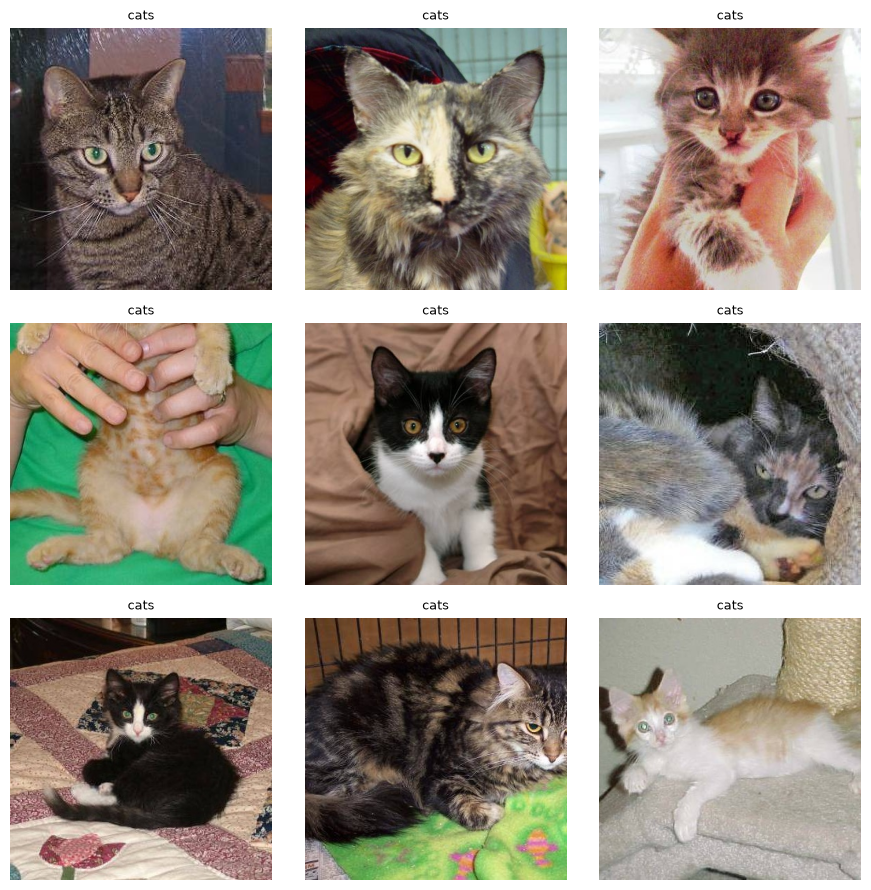

In [8]:
import matplotlib.pyplot as plt

sample = sorted(OUT_CROP.rglob("*.jpg"))[:9]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, p in zip(axes.ravel(), sample):
    ax.imshow(Image.open(p)); ax.set_title(p.parent.name, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

In [9]:
for cov in [0.5, 0.75, 0.9]:
    tag = f"{int(cov*100):03d}"
    build_dataset(model, SRC, Path(f"out/train_crop{tag}"), OUT_MISSING, cov,
                  conf=CONF, batch=BATCH, limit=LIMIT, exts=EXTS,
                  bbox_csv=None, device=DEVICE)
    print()

8000 imagenes en content/cats-and-dogs-for-classification/cats_dogs/train  |  coverage=0.5
  recortadas:                     7050
  sin animal (a missing):         950
  caja > coverage pedido:         6902
  cobertura real p5/25/50/75/95: [       0.63        0.89           1           1           1]

8000 imagenes en content/cats-and-dogs-for-classification/cats_dogs/train  |  coverage=0.75
  recortadas:                     7050
  sin animal (a missing):         950
  caja > coverage pedido:         6184
  cobertura real p5/25/50/75/95: [       0.75        0.89           1           1           1]

8000 imagenes en content/cats-and-dogs-for-classification/cats_dogs/train  |  coverage=0.9
  recortadas:                     7050
  sin animal (a missing):         950
  caja > coverage pedido:         4911
  cobertura real p5/25/50/75/95: [        0.9         0.9           1           1           1]



In [10]:
def size_stats(folder, exts=(".jpg", ".jpeg", ".png")):
    """Distribucion de ancho/alto de un dataset de imagenes."""
    folder = Path(folder)
    ws, hs = [], []
    for p in folder.rglob("*"):
        if p.suffix.lower() in exts:
            with Image.open(p) as im:
                w, h = im.size          # PIL: (ancho, alto)
            ws.append(w); hs.append(h)

    if not ws:
        print(f"{folder}: sin imagenes"); return
    ws, hs = np.array(ws), np.array(hs)
    pct = [0, 5, 25, 50, 75, 95, 100]   # 0 = min, 100 = max

    print(f"{folder}  ({len(ws)} imagenes)")
    print(f"  ancho  min/max: {ws.min()} / {ws.max()}")
    print(f"  alto   min/max: {hs.min()} / {hs.max()}")
    print("  percentiles       :", "  ".join(f"p{p}" for p in pct))
    print("  ancho             :", "  ".join(f"{int(v)}" for v in np.percentile(ws, pct)))
    print("  alto              :", "  ".join(f"{int(v)}" for v in np.percentile(hs, pct)))
    # lado menor: manda para decidir a que resolucion puedes entrenar sin inventar pixeles
    short = np.minimum(ws, hs)
    print("  lado menor        :", "  ".join(f"{int(v)}" for v in np.percentile(short, pct)))
    return {"w": ws, "h": hs}

# uso:
size_stats(OUT_CROP)        # el dataset recortado
size_stats(OUT_MISSING)     # las que YOLO no detecto (originales, para comparar)

out/train_crop075  (7050 imagenes)
  ancho  min/max: 66 / 768
  alto   min/max: 66 / 768
  percentiles       : p0  p5  p25  p50  p75  p95  p100
  ancho             : 66  191  288  360  375  464  768
  alto              : 66  191  288  360  375  464  768
  lado menor        : 66  191  288  360  375  464  768
out/train_no_animal  (950 imagenes)
  ancho  min/max: 57 / 500
  alto   min/max: 41 / 500
  percentiles       : p0  p5  p25  p50  p75  p95  p100
  ancho             : 57  107  199  297  399  500  500
  alto              : 41  102  190  269  374  499  500
  lado menor        : 41  99  172  243  355  430  499


{'w': array([150, 500, 300, 279, 359, 500, 434, 134, 375, 266, 350, 299, 319, 320, 346, 149, 149, 319, 500, 499, 342, 287, 228, 500, 360, 288, 284, 179, 500, 121, 319, 152,  90, 150,  80, 185, 299, 500, 306, 405, 143, 377, 263, 199, 400, 320, 282, 199, 500, 350, 250, 150, 417, 100, 217, 318, 236, 208, 350, 265, 206, 278,
        266,  99, 240, 420, 390, 243, 219, 189, 240, 185, 499, 460, 199, 395, 105,  90,  99, 349, 179, 499, 126, 235, 320, 206, 350, 149, 124, 319, 499, 193, 238, 197, 199, 125, 319, 499, 309, 149, 149, 499,  75, 120, 368, 258, 199, 110, 139, 234, 399, 215, 373, 344, 499, 500, 162, 135, 500, 230, 200, 287, 499, 500,
        139, 249,  59, 352, 227, 499, 227, 500, 357, 350, 284, 293, 249, 149, 319, 156, 153, 359, 207, 230, 135, 149, 140, 249, 350, 189, 300, 199, 181, 500, 109, 299, 188, 174, 499, 244, 500,  96, 320, 500, 255, 191, 139, 499, 155, 200, 155, 150, 400, 499, 303, 350, 229, 500, 176, 500,  99, 136, 250, 499, 159, 160,
        499, 499, 439, 184, 200, 215, 384